1. Connect to the Database using the `get_connection() function

In [4]:
import psycopg2
import pandas as pd

# --- Database connection string---
SUPABASE_HOST = "aws-0-ap-southeast-1.pooler.supabase.com"
SUPABASE_PORT = 6543
SUPABASE_DB = "postgres"
SUPABASE_USER = "postgres.laremattjpwkgpmwitzv"
SUPABASE_PASSWORD = "Wombat2025@@!!"

def get_connection():
    return psycopg2.connect(
        host=SUPABASE_HOST,
        port=SUPABASE_PORT,
        dbname=SUPABASE_DB,
        user=SUPABASE_USER,
        password=SUPABASE_PASSWORD,
        sslmode="require"
    )


2. Example queries using `with get_connection() as conn:`

In [ ]:
# Example 1: Look at first 5 rows
with get_connection() as conn:
    df = pd.read_sql("SELECT * FROM pre_data LIMIT 5;", conn)
print(df)

In [ ]:
# Example 2: Count rows
with get_connection() as conn:
    count_df = pd.read_sql("SELECT COUNT(*) AS total_rows FROM pre_data;", conn)
print(count_df)


In [ ]:
# Example 3: Get all data of a single fund:
with get_connection() as conn:
    df_hesta = pd.read_sql("SELECT * FROM pre_data WHERE fund_name = 'HESTA';", conn)
    df_hesta.info()


In [ ]:
# Example 4: Aggregate data - total value by fund, top 10 funds by total value
query = """
SELECT fund_name, SUM(value_aud) AS total_value
FROM pre_data
GROUP BY fund_name
ORDER BY total_value DESC
LIMIT 10;
"""
with get_connection() as conn:
    fund_value = pd.read_sql(query, conn)
print(fund_value)


In [ ]:
# Example 5: Get all fund names

query = "SELECT DISTINCT fund_name FROM pre_data;"
with get_connection() as conn:
    fund_names = pd.read_sql(query, conn)
print(fund_names)

In [ ]:
# Example 6: Summary statistics for numeric columns
# List of numeric columns

query = """
SELECT * FROM pre_data
"""
with get_connection() as conn:
    df_all = pd.read_sql(query, conn)

numeric_cols = ['value_aud', 'units_held', 'ownership_percentage', 'weighting']

print("Summary statistics for numeric columns:")
print(df_all[numeric_cols].describe())


C:\Users\Admin\AppData\Local\Temp\ipykernel_37512\3322158528.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_funds.values, y=top_funds.index, palette='viridis')


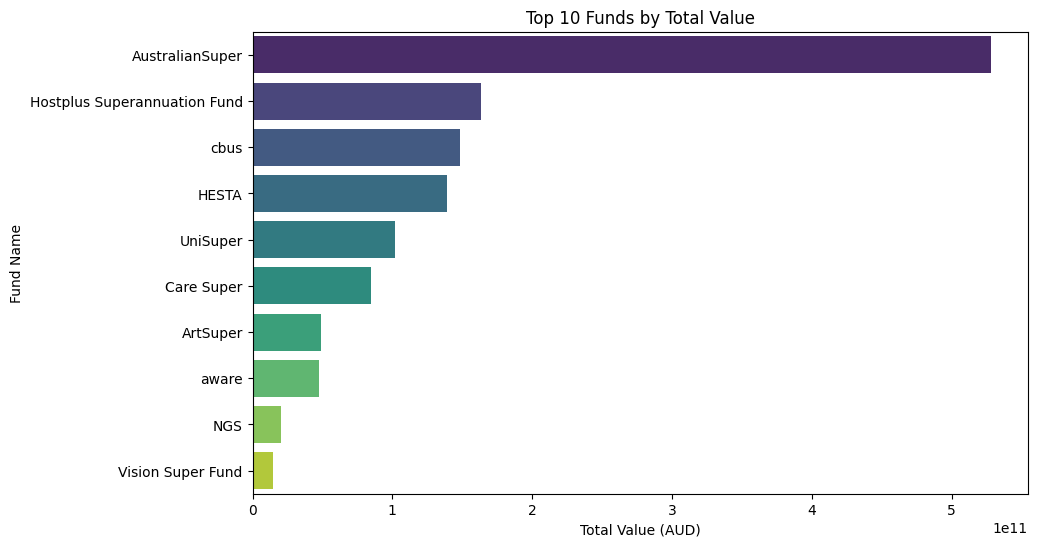

In [ ]:
# Example 7: Visualisation of some values
import matplotlib.pyplot as plt
import seaborn as sns

# value_aud by funds
top_funds = df_all.groupby('fund_name')['value_aud'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_funds.values, y=top_funds.index, palette='viridis')
plt.xlabel('Total Value (AUD)')
plt.ylabel('Fund Name')
plt.title('Top 10 Funds by Total Value')
plt.show()



C:\Users\Admin\AppData\Local\Temp\ipykernel_37512\4010242916.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=asset_alloc.values, y=asset_alloc.index, palette='viridis')


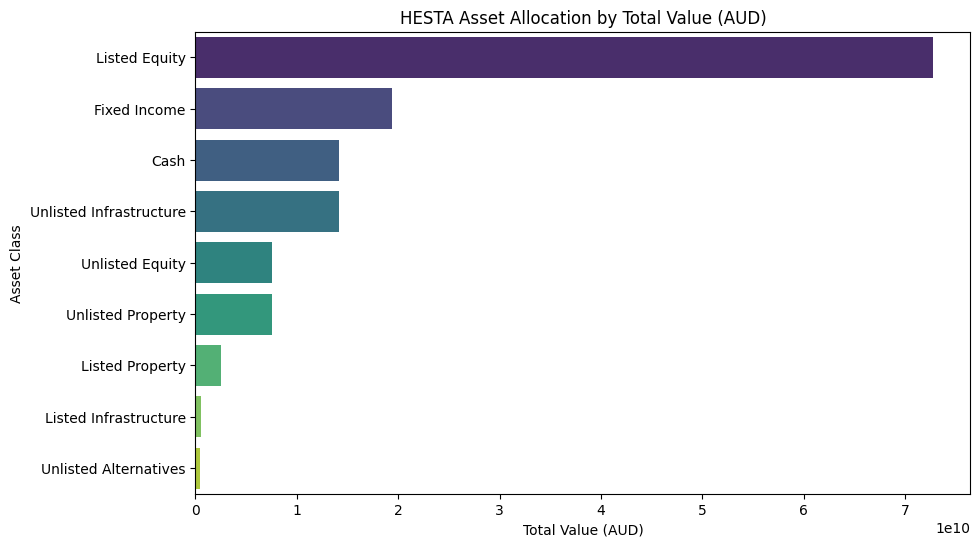

In [17]:
# Asset allocation for hesta

# Aggregate total value by asset class
asset_alloc = df_hesta.groupby('asset_class_name')['value_aud'].sum().sort_values(ascending=False)

# bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=asset_alloc.values, y=asset_alloc.index, palette='viridis')
plt.xlabel('Total Value (AUD)')
plt.ylabel('Asset Class')
plt.title('HESTA Asset Allocation by Total Value (AUD)')
plt.show()



**Column mapping/ Data dictionary**:

| CSV Column Name              | Database Column Name   | Description                              |
| ---------------------------- | ---------------------- | ---------------------------------------- |
| Effective Date               | effective\_date        | Date when the portfolio is effective     |
| Fund Name                    | fund\_name             | Name of the super fund                   |
| Option Name                  | option\_name           | Investment option within the fund        |
| Asset Class Name             | asset\_class\_name     | Category like Equity, Fixed Income, etc. |
| Int/Ext                      | int\_ext               | Internal / External classification       |
| Name/Kind of Investment Item | investment\_item\_name | Specific investment name                 |
| Currency                     | currency               | Currency code                            |
| Stock ID                     | stock\_id              | Identifier or ticker                     |
| Listed Country               | listed\_country        | Country of listing                       |
| Units Held                   | units\_held            | Number of units/shares                   |
| % Ownership                  | ownership\_percentage  | Ownership percentage (0-1)             |
| Address                      | address                | Address of investment                    |
| Value (AUD)                  | value\_aud             | Market value in AUD                      |
| Weighting (%)                | weighting | Portfolio weighting (0-1)          |

**Data categorization**:
| Data Type                  | Columns                                                                             |
| -------------------------- | ----------------------------------------------------------------------------------- |
| **Descriptive / Text**     | option\_name, investment\_item\_name, address, currency, stock\_id, listed\_country |
| **Company / Fund Names**   | fund\_name                                                                          |
| **Numeric / Quantitative** | units\_held, ownership\_percentage, value\_aud, weighting               |
| **Dates**                  | effective\_date                                                                     |
| **Categorical**            | asset\_class\_name, int\_ext                                                        |


**Json schema example**:

```json
{
  "effective_date": "2024-12-31",
  "fund_name": "HESTA",
  "option_name": "Balanced Growth",
  "asset_class_name": "Listed Equity",
  "int_ext": "1",
  "investment_item_name": "BANK OF AMERICA",
  "currency": "AUD",
  "stock_id": "2100845",
  "listed_country": "Australia",
  "units_held": 11059401.87,
  "ownership_percentage": 0.0362,
  "address": "Melbourne, Australia",
  "value_aud": 987654321.12,
  "weighting": 0.0011
}
```